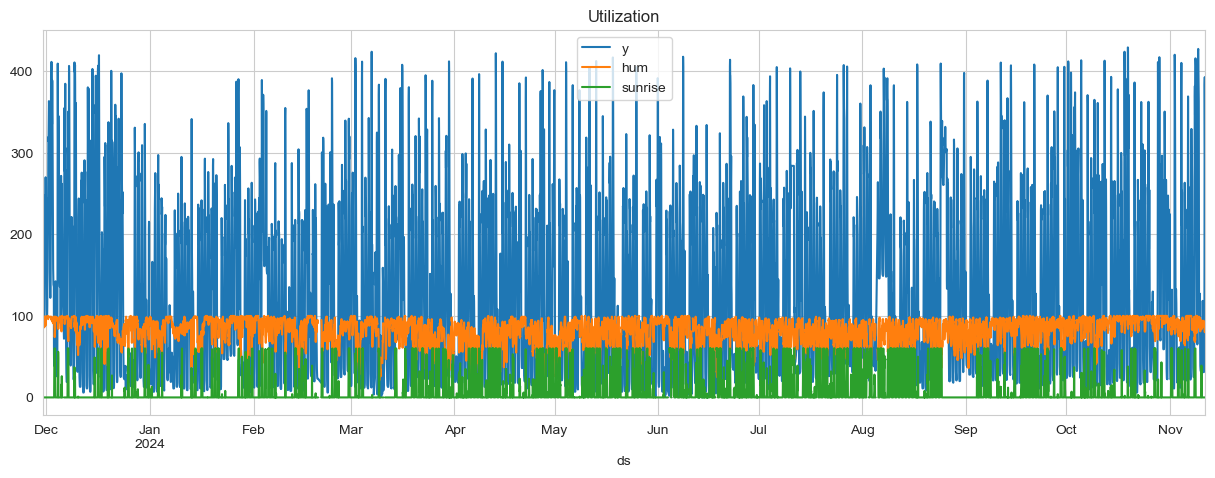

In [381]:
from dateutil.relativedelta import relativedelta
import pandas as pd
from neuralprophet import NeuralProphet, set_log_level, set_random_seed
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
set_log_level("ERROR")

data = pd.read_csv('./data/out_hourly.csv')
df = pd.DataFrame(data)
df['tsun'] = df['tsun'].fillna(0)
df_p = pd.DataFrame({
    'ds': df['timestamp'],
    'y': df['value'],
    'hum': df['rhum'],
    'sunrise': df['tsun'],
})
df_p['ds'] = pd.to_datetime(df_p['ds'])

df_events = df[['timestamp', 'event_name']]
df_events = df_events[df_events['event_name'].notna()]
df_events['ds'] = pd.to_datetime(df_events['timestamp']).dt.date
df_events = df_events.drop_duplicates(subset=['ds', 'event_name'])
df_events = df_events.drop('timestamp', axis=1)
df_chris = df_events[df_events['event_name'] == 'Christkindlemarkt']
df_events = df_events[df_events['event_name'] != 'Christkindlemarkt']
df_events['ds'] = pd.to_datetime(df_events['ds'])
date_list_events = df_events['ds'].tolist()
df_chris['ds'] = pd.to_datetime(df_chris['ds'])
date_list_chris = df_chris['ds'].tolist()

df_event = pd.DataFrame({
    "event": "dornbirn_events",
    "ds": date_list_events,
})
df_chri = pd.DataFrame({
    "event": "Christkindlemarkt",
    "ds": date_list_chris,
})

df_tag = df_p[(df_p['ds'] >= pd.to_datetime('2024-05-21')) & (df_p['ds'] < pd.to_datetime('2024-05-22'))]
df_tag.loc[:,'ds'] = df_tag['ds'].apply(lambda x: x - relativedelta(days=14))
df_p = pd.concat([df_p, df_tag], ignore_index=True)

df_tag2 = df_p[(df_p['ds'] >= pd.to_datetime('2024-08-10')) & (df_p['ds'] < pd.to_datetime('2024-08-11'))]
df_tag2.loc[:,'ds'] = df_tag2['ds'].apply(lambda x: x - relativedelta(days=7))
df_p = pd.concat([df_p, df_tag2], ignore_index=True)

df_tag3 = df_p[(df_p['ds'] >= pd.to_datetime('2024-07-28')) & (df_p['ds'] < pd.to_datetime('2024-07-29'))]
df_tag3.loc[:,'ds'] = df_tag3['ds'].apply(lambda x: x + relativedelta(days=7))
df_p = pd.concat([df_p, df_tag3], ignore_index=True)

df_p = df_p.sort_values('ds')
df_p = df_p.reset_index(drop=True)

df_p = df_p.set_index('ds')
full_range = pd.date_range(df_p.index.min(), df_p.index.max(), freq='H')
df_p = df_p.reindex(full_range)
df_p['y'] = df_p['y'].interpolate()  # lineare Interpolation
df_p = df_p.reset_index().rename(columns={'index': 'ds'})

"""
def tage_mit_fehlerhaften_stunden(df, ds_col='ds'):
    df = df.copy()
    df['date'] = df[ds_col].dt.date
    df['hour'] = df[ds_col].dt.hour
    stunden_pro_tag = df.groupby('date')['hour'].nunique()
    return stunden_pro_tag[stunden_pro_tag < 24]

print(tage_mit_fehlerhaften_stunden(df_p, ds_col='ds'))
"""

plt = df_p.plot(title= "Utilization", x="ds", y=['y', 'hum', 'sunrise'], figsize=(15, 5))

confidence_level = 0.9
quantiles_list = [round((1 - confidence_level) / 2, 2), round((confidence_level + (1 - confidence_level) / 2), 2)]
# NeuralProphet only accepts quantiles value in between 0 and 1
#quantiles = [boundaries, confidence_level + boundaries]

m = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_lags=168,
    learning_rate=0.01,
    quantiles=quantiles_list)
m2 = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_lags=168,
    ar_layers=[32, 32, 32, 32],
    learning_rate=0.01,
    quantiles=quantiles_list
)
m2.set_plotting_backend("plotly-static")
m.set_plotting_backend('plotly-static')
m = m.add_country_holidays("AT")
m2 = m2.add_country_holidays("AT")
m.add_lagged_regressor('hum', n_lags=4)
m2.add_lagged_regressor('hum', n_lags=4)
m.add_lagged_regressor('sunrise', n_lags=3)
m2.add_lagged_regressor('sunrise', n_lags=3)
m.add_events('dornbirn_events')
m2.add_events('dornbirn_events')
m.add_events('Christkindlemarkt')
m2.add_events('Christkindlemarkt')
df_with_event = m.create_df_with_events(df_p, df_event)
df_with_events = m.create_df_with_events(df_with_event, df_chri)


Training: 0it [00:00, ?it/s]

Testing: 0it [00:00, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Runningstage.testing metric      DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        Loss_test           0.23920562863349915
         MAE_val            22.694007873535156
        RMSE_val            31.067325592041016
      RegLoss_test                  0.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Training: 0it [00:00, ?it/s]

Testing: 0it [00:00, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Runningstage.testing metric      DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        Loss_test           0.10063708573579788
         MAE_val             39.60376739501953
        RMSE_val             67.5391616821289
      RegLoss_test                  0.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,MAE_val,RMSE_val,Loss_test,RegLoss_test
0,39.603767,67.539162,0.100637,0.0


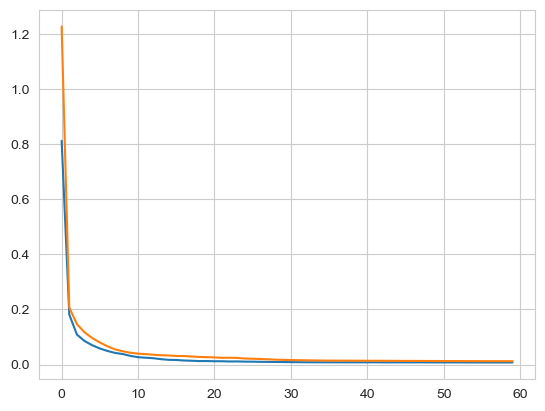

In [382]:
# evaluate uncertainy on calibration set
train_df, test_df = m.split_df(df_with_events, freq='H', valid_p=1.0 / 11, local_split=True)
train_df.shape, test_df.shape
# Fit the model on the dataset
train_df, cal_df = m.split_df(train_df, freq="H", valid_p=1.0 / 16)
## Add calibration set using the data splitting function
train_df.shape, cal_df.shape, test_df.shape
set_random_seed(0)
metrics = m.fit(train_df, freq='H', progress='plot')
metrics_testc = m.test(test_df)
metrics_testc
set_random_seed(0)
metrics2 = m2.fit(train_df, freq="H", progress='plot')
metrics_test2 = m2.test(test_df)
metrics_test2


Predicting: 109it [00:00, ?it/s]

Predicting: 109it [00:00, ?it/s]

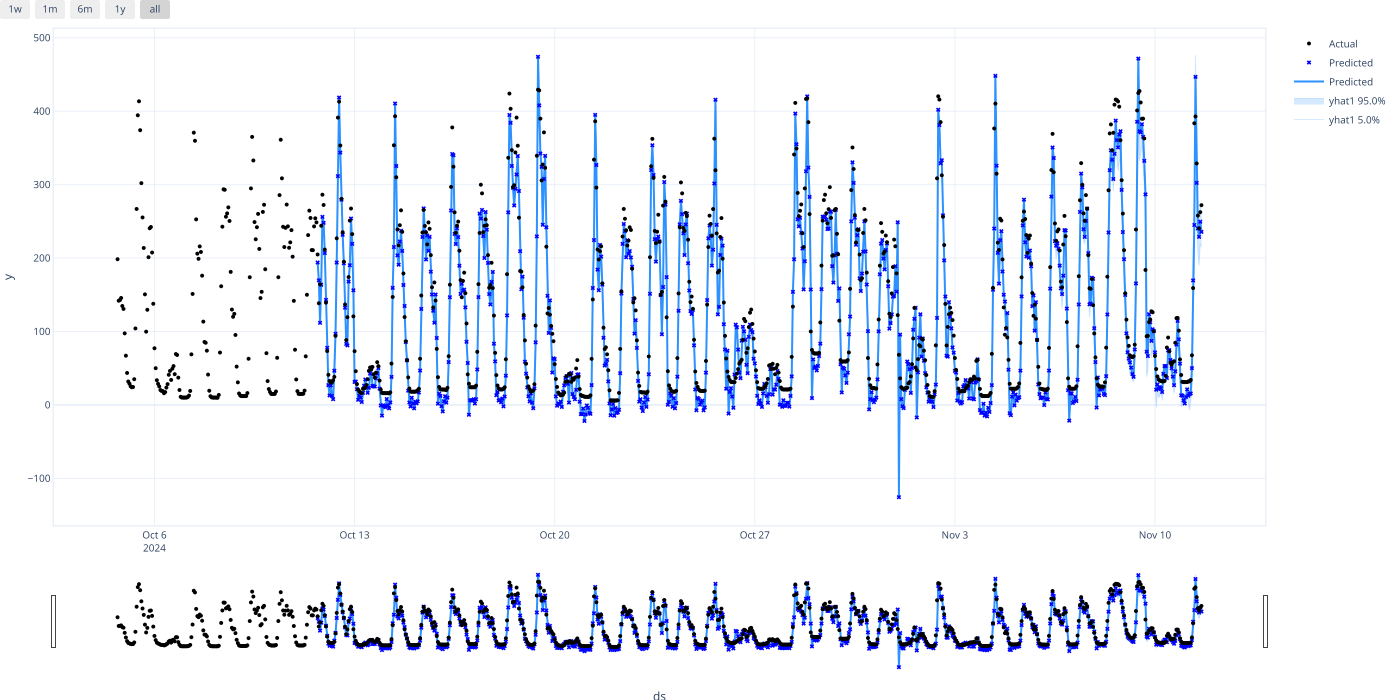

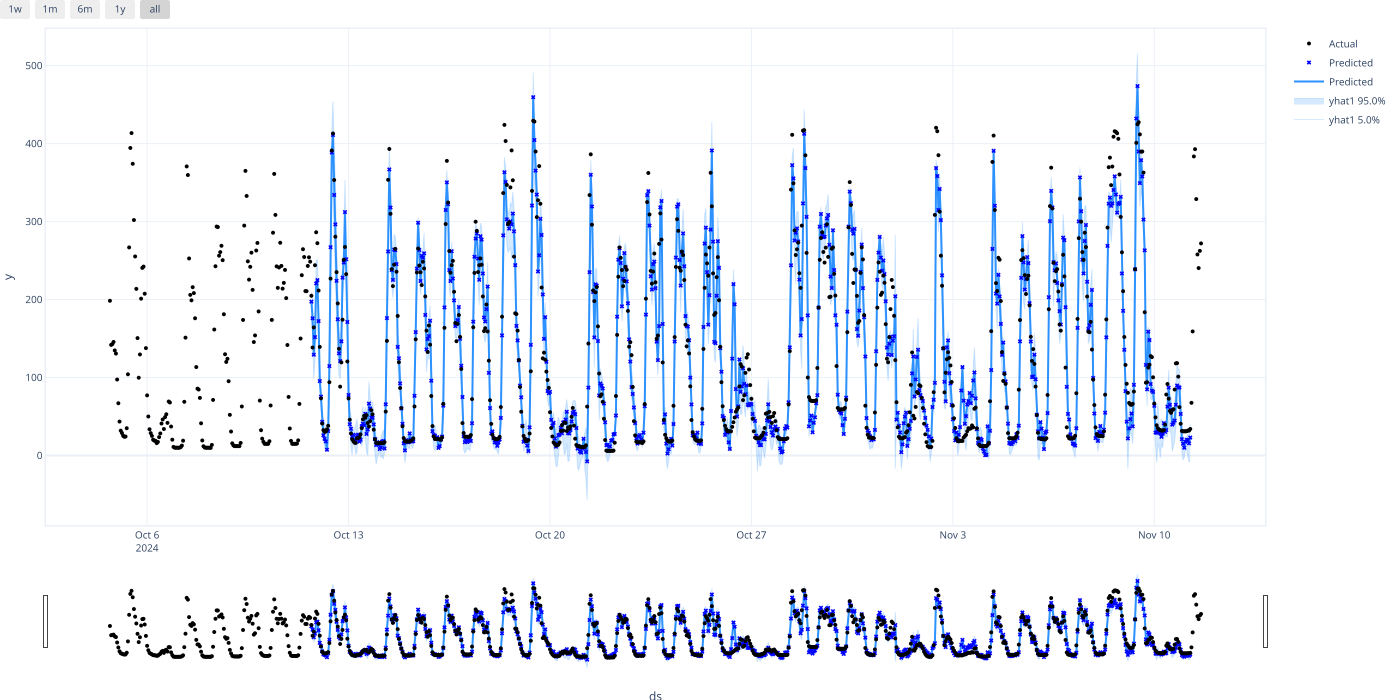

Dataset size: 8344
Train dataset size: 7137
Validation dataset size: 911


In [383]:

# Create a new dataframe reaching 365 into the future for our forecast, n_historic_predictions also shows historic data
#df_future = m2.make_future_dataframe(train_df, periods=30, n_historic_predictions=100)
#df_forecast = m.predict(df_future)
#m.highlight_nth_step_ahead_of_each_forecast(1).plot(df_future)
forecast = m.predict(test_df) #[168:]
forecast2 = m2.predict(test_df) #[168:]
#print(forecast)


#m.highlight_nth_step_ahead_of_each_forecast(1).plot(forecast, figsize=(20, 8))
m.highlight_nth_step_ahead_of_each_forecast(1).plot(forecast, figsize=(20, 10), forecast_in_focus=1)
m2.highlight_nth_step_ahead_of_each_forecast(1).plot(forecast2, figsize=(20, 10), forecast_in_focus=1)
print("Dataset size:", len(df_with_events))
print("Train dataset size:", len(train_df))
print("Validation dataset size:", len(test_df))



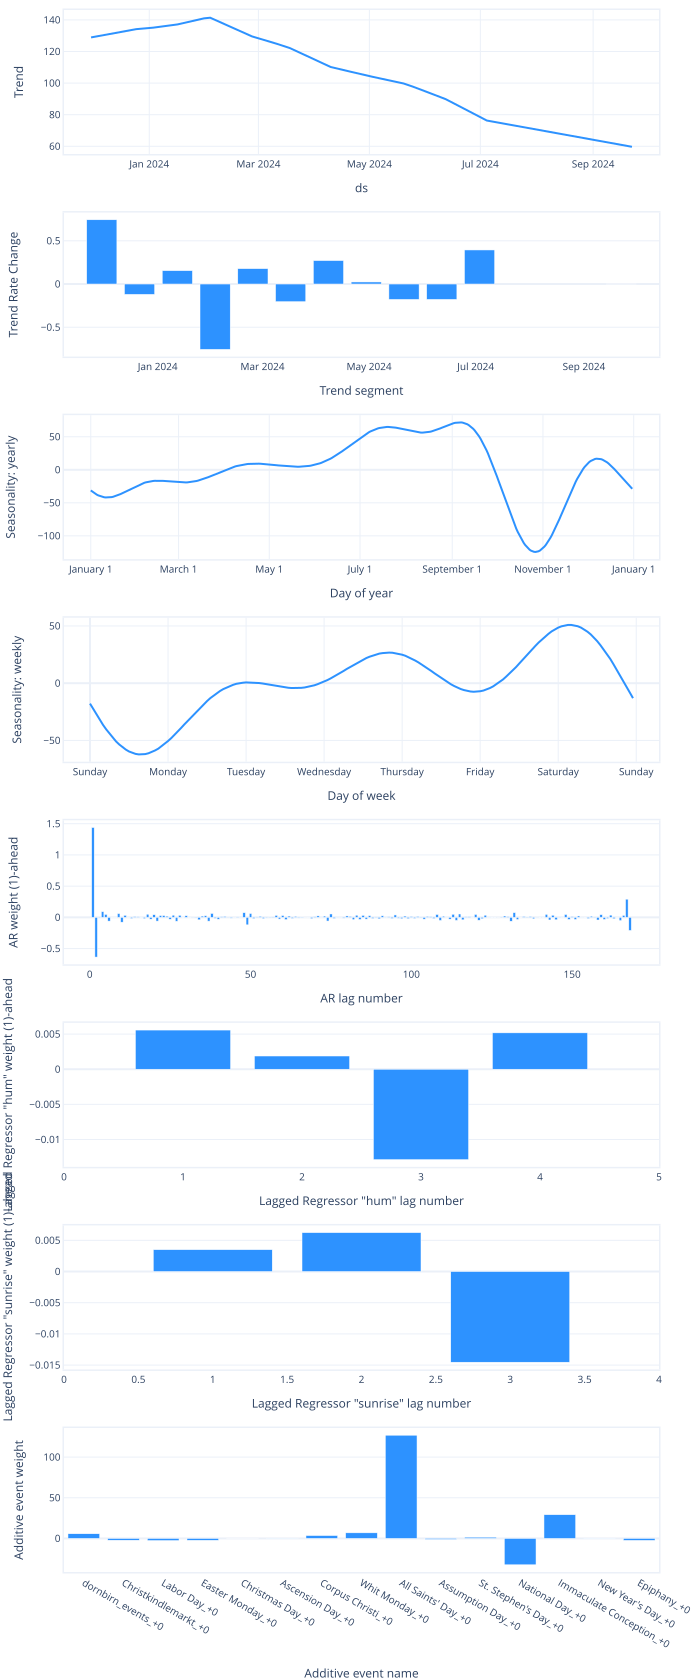

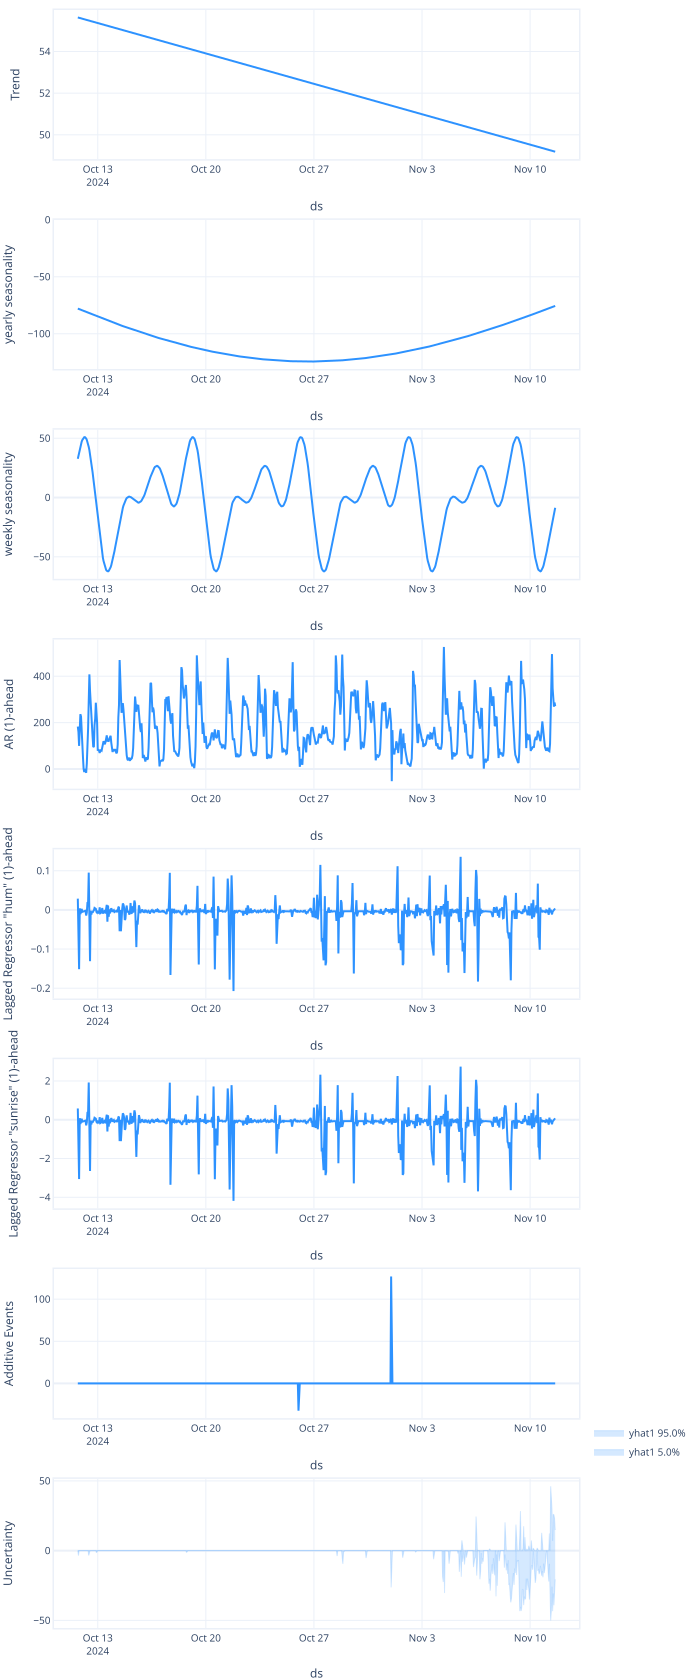

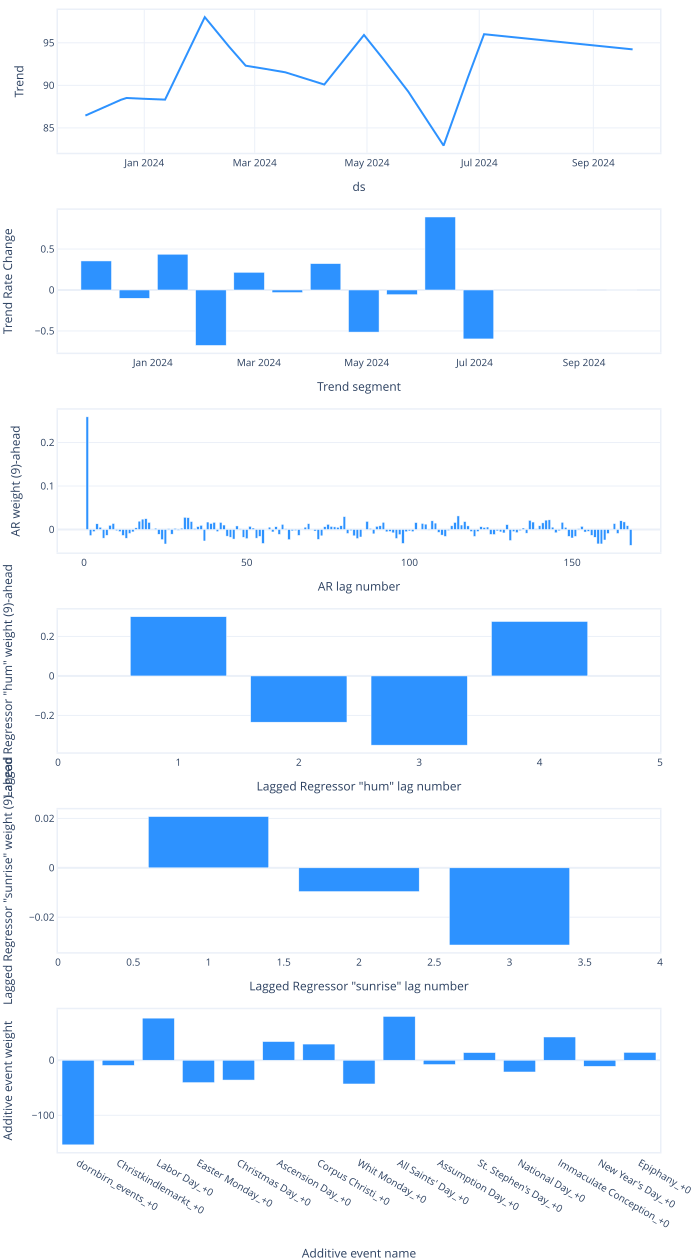

KeyError: 'ar9'

In [384]:
m.plot_parameters()
m.plot_components(conformal_forecast)
m2.plot_parameters()
m2.plot_components(conformal_forecast2)


Predicting: 109it [00:00, ?it/s]

Predicting: 109it [00:00, ?it/s]

Predicting: 109it [00:00, ?it/s]

Predicting: 109it [00:00, ?it/s]

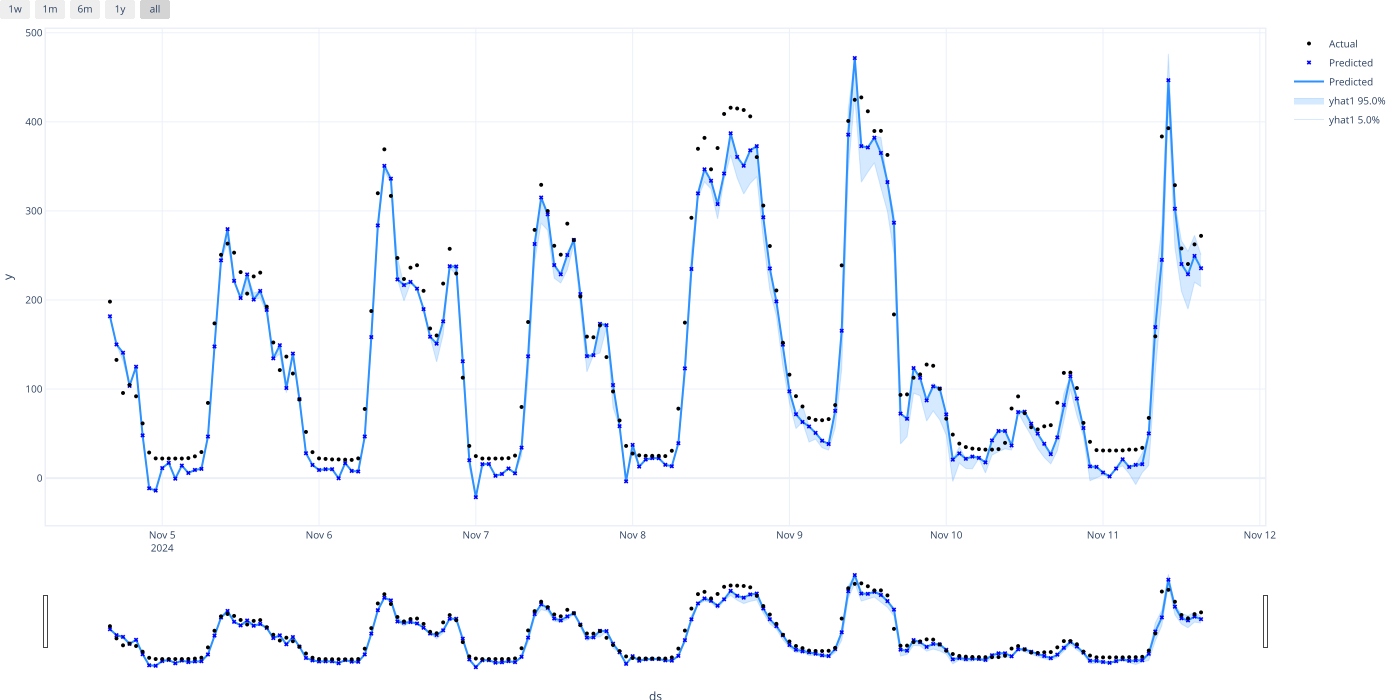

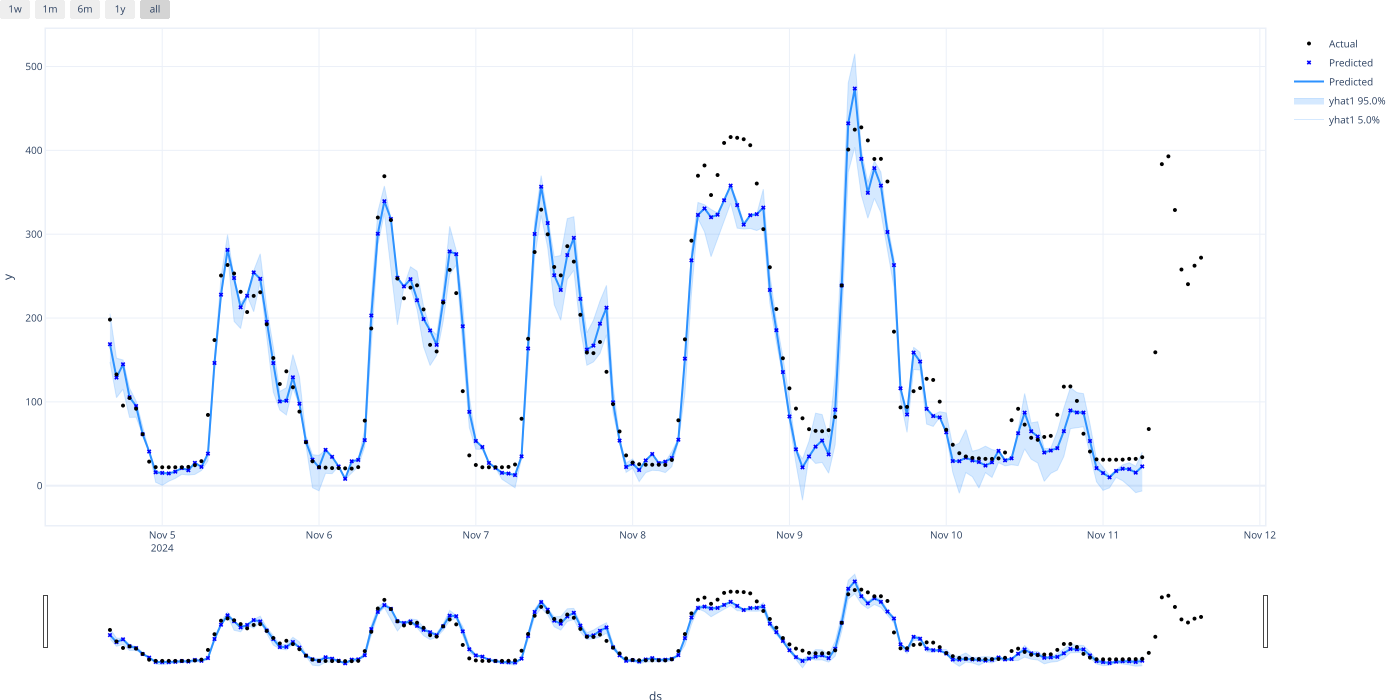

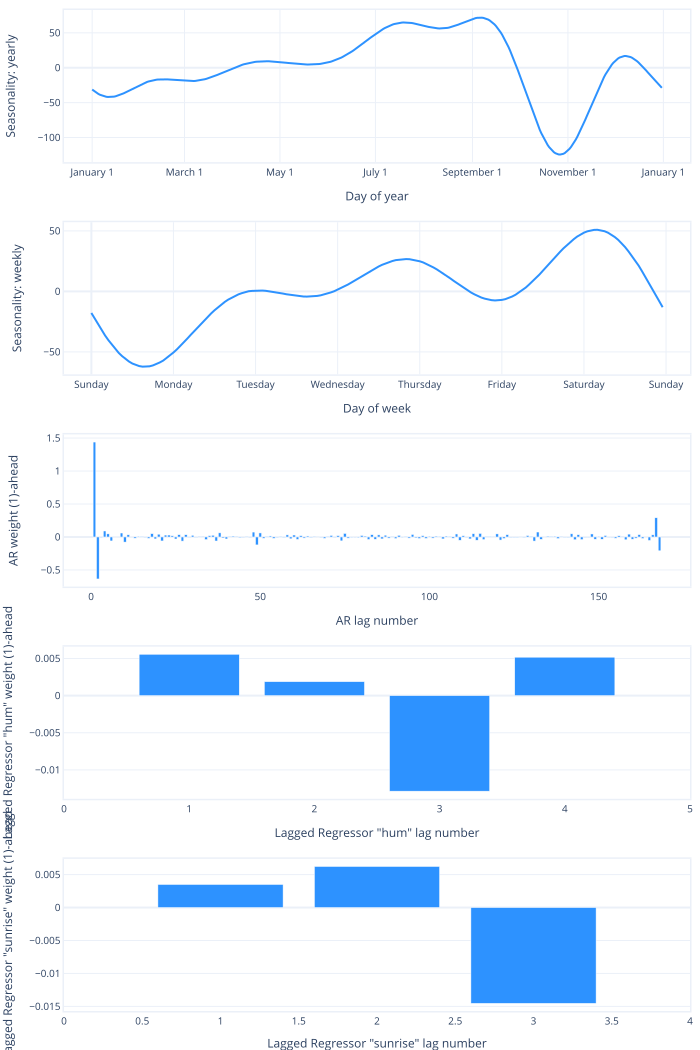

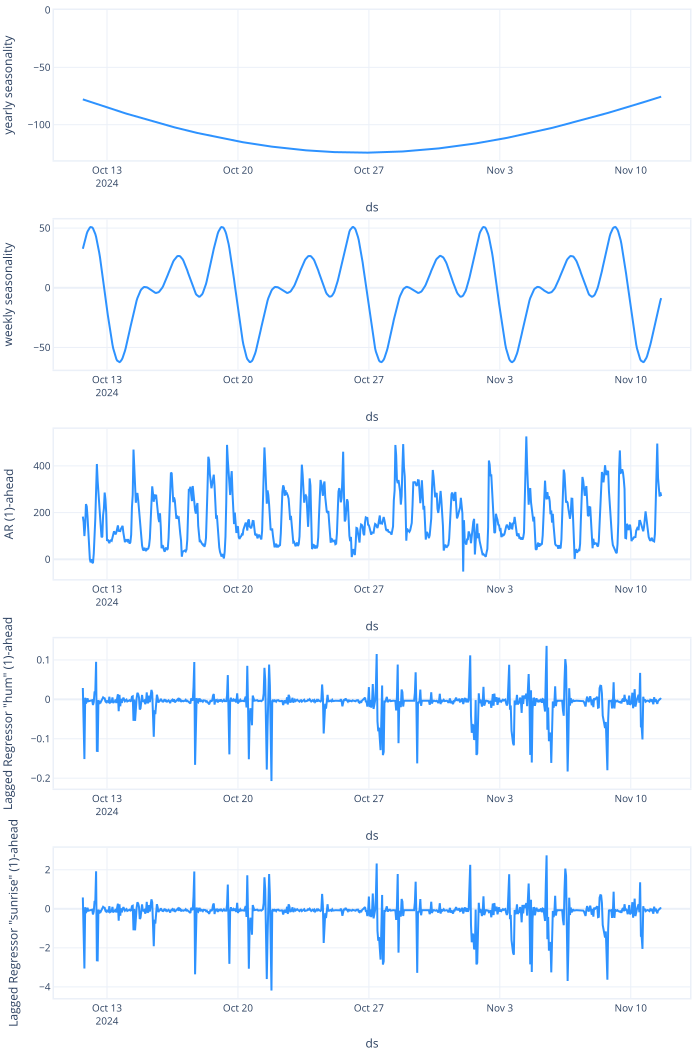

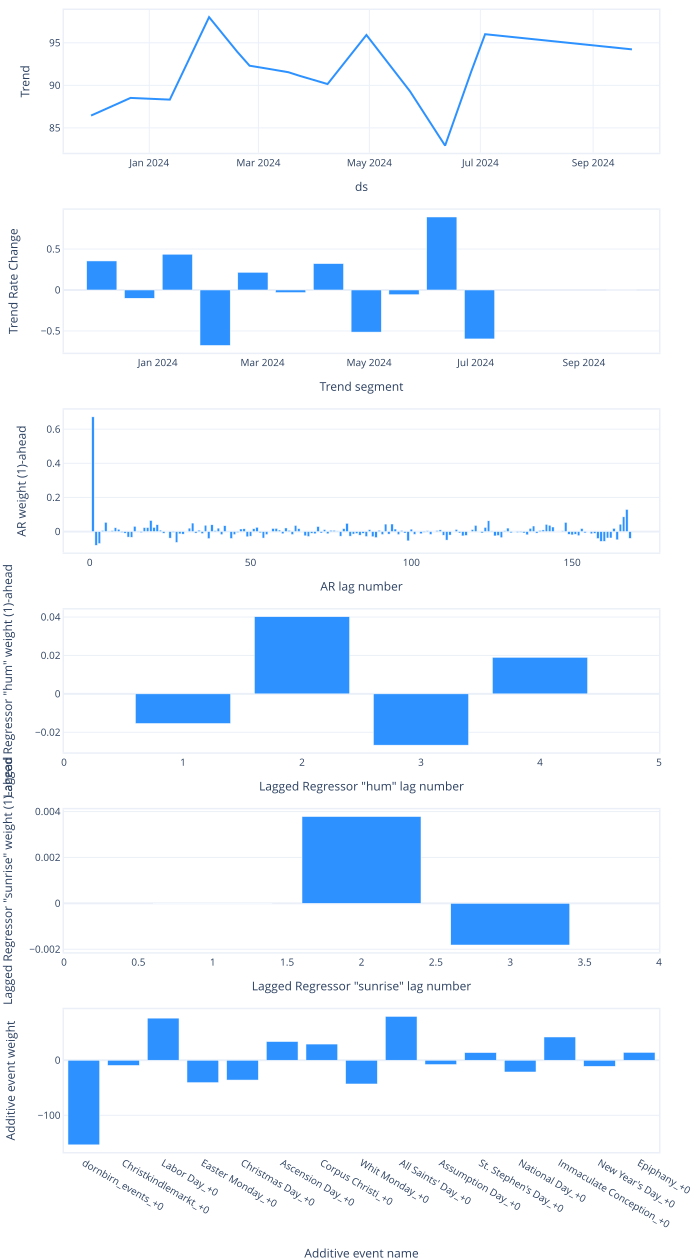

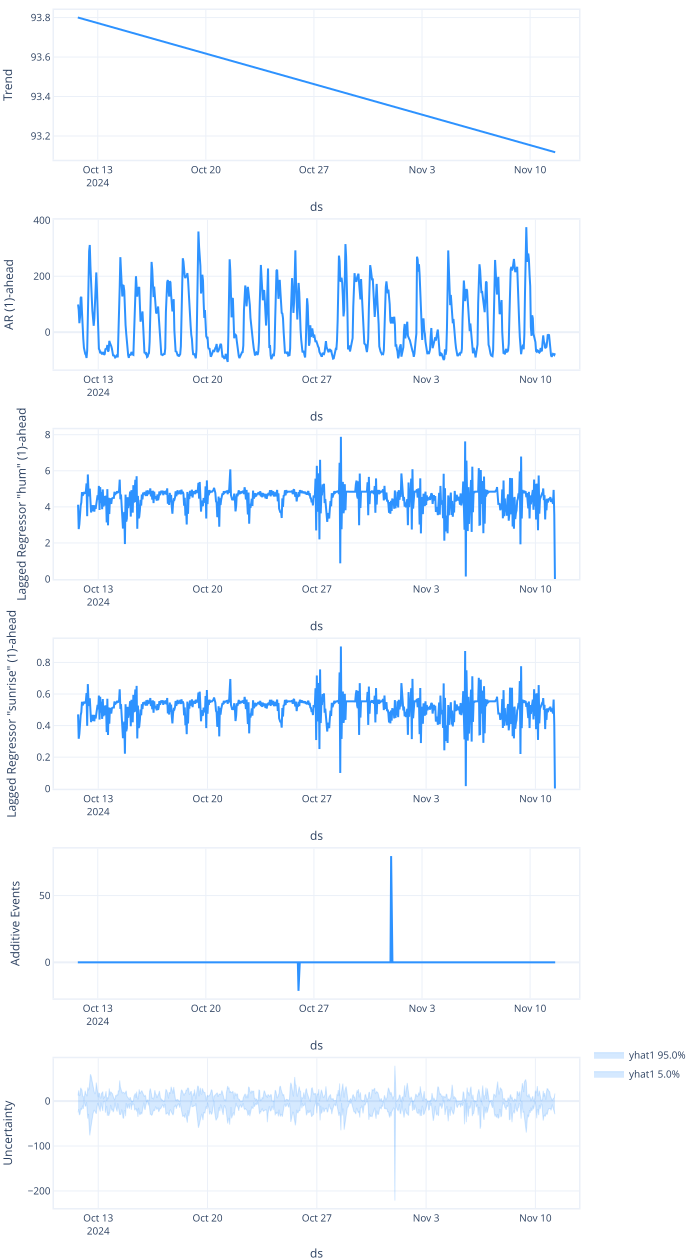

In [385]:

method = "naive"  # or "cqr" for a more sophisticated method, see uncertainty tutorial
alpha = 1 - confidence_level
conformal_forecast = m.conformal_predict(
    test_df,
    calibration_df=cal_df,
    alpha=alpha,
    method=method,
    plotting_backend="plotly-static",
    show_all_PI=True,
)
conformal_forecast2 = m2.conformal_predict(
    test_df,
    calibration_df=cal_df,
    alpha=alpha,
    method=method,
    plotting_backend="plotly-static",
    show_all_PI=True,
)

naive_qhat1 = conformal_forecast.iloc[-1]["yhat1"] - conformal_forecast.iloc[-1]["yhat1 - qhat1"]  # cp_model1
naive_qhat2 = conformal_forecast2.iloc[-1]["yhat1"] - conformal_forecast2.iloc[-1]["yhat1 - qhat1"]  # cp_model2
naive_qhat1, naive_qhat2
# Date range shown in the plots (optional)
cutoff = 7 * 24

fig1 = m.highlight_nth_step_ahead_of_each_forecast(1).plot(
    conformal_forecast[-cutoff:], plotting_backend="plotly-static", figsize=(20, 10)
)
fig2 = m2.highlight_nth_step_ahead_of_each_forecast(1).plot(
    conformal_forecast2[-cutoff:], plotting_backend="plotly-static", figsize=(20, 10)
)
#m.highlight_nth_step_ahead_of_each_forecast(1).plot(conformal_forecast, figsize=(20, 10))

m.plot_parameters(components=['seasonality', 'autoregression', "lagged_regressors"])
m.plot_components(conformal_forecast, components=['seasonality', 'autoregression', "lagged_regressors"])
m2.plot_parameters()
m2.plot_components(conformal_forecast2)

#The residuals are the difference between the model’s prediction and the real data. If the model is perfect, the residuals should be zero.
#df_residuals = pd.DataFrame({"ds": df_with_events["ds"], "residuals": df_with_events["y"] - conformal_forecast2["yhat1"]})
#fig = df_residuals.plot(x="ds", y="residuals", figsize=(15, 8))

#autoregression
#plt = plot_acf(df_residuals["residuals"], lags=168)


Finding best initial lr:   0%|          | 0/246 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Predicting: 112it [00:00, ?it/s]

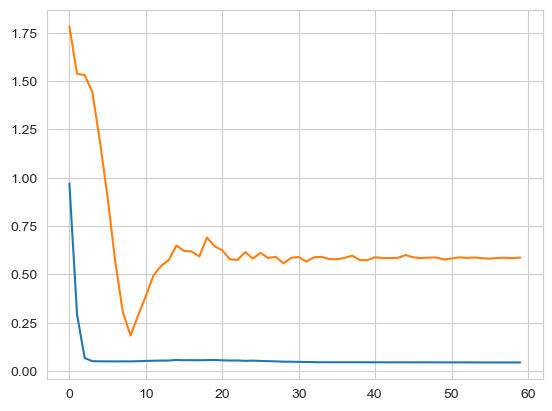

In [388]:
train_df = train_df.drop(['hum', 'sunrise'], axis=1)
test_df = test_df.drop(['hum', 'sunrise'], axis=1)
m2 = NeuralProphet(yearly_seasonality=True, weekly_seasonality=True)
m2.set_plotting_backend('plotly-static')
m2 = m2.add_country_holidays("AT")
m2.add_events('dornbirn_events')
m2.add_events('Christkindlemarkt')
metrics_train2 = m2.fit(train_df, freq='H', validation_df= test_df, progress='plot')
future = m2.make_future_dataframe(train_df, periods=288, n_historic_predictions=True)
forecast2 = m2.predict(future)
m2.plot(forecast2, figsize=(20, 10), forecast_in_focus=1)

In [ ]:

df_ps = pd.DataFrame({
    'ds': df_p['ds'],
    'y': df_p['y'],
})

m3 = NeuralProphet(n_changepoints=10, weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, learning_rate=0.01, n_lags=168, growth='off')

m3.set_plotting_backend("plotly-static")
m3 = m3.add_country_holidays("AT")
m3.add_events('dornbirn_events')
m3.add_events('Christkindlemarkt')
df_with_event3 = m3.create_df_with_events(df_ps, df_event)
df_with_events3 = m3.create_df_with_events(df_with_event3, df_chri)
#df_train2, df_test2 = m3.split_df(df_with_events3, freq="H", valid_p=0.1)
# create a test holdout set:
df_train_val, df_test3 = m3.split_df(df=df_with_events3, freq="H", valid_p=0.2)
# create a validation holdout set:
df_train, df_val = m3.split_df(df=df_train_val, freq="H", valid_p=0.2)

metrics = m3.fit(df_train, freq="H", validation_df=df_val, progress='plot')
metrics_test3 = m3.test(df=df_val)
metrics_test3
future = m3.make_future_dataframe(df_train, periods=288, n_historic_predictions=True)
forecast = m3.predict(future)
print(forecast)
m3.plot(forecast, figsize=(20, 10), forecast_in_focus=1)
m3.plot_parameters(components=["trend", "seasonality"])
m3.plot_components(forecast)
df_residuals = pd.DataFrame({"ds": df_with_events3["ds"], "residuals": df_with_events3["y"] - forecast["yhat1"]})
fig = df_residuals.plot(x="ds", y="residuals", figsize=(10, 6))
# refit model on training and validation data and evaluate on test set.
m3 = NeuralProphet()
m3.set_plotting_backend("plotly-static")
m3 = m3.add_country_holidays("AT")
m3.add_events('dornbirn_events')
m3.add_events('Christkindlemarkt')
metrics_train3 = m3.fit(df=df_train_val, freq="H", validation_df=df_test3, progress='plot')
metrics_test = m3.test(df=df_test3)
metrics_train1["split"] = "train1"
metrics_train2["split"] = "train2"
metrics_val["split"] = "validate"
metrics_test["split"] = "test"
#metrics_train1.tail(1).append([metrics_train2.tail(1), metrics_val, metrics_test]).drop(columns=["RegLoss"])
metrics_train1 = pd.concat([
    metrics_train1.tail(1),
    metrics_train2.tail(1),
    metrics_val,
    metrics_test
], ignore_index=True)
# Spalte "RegLoss" entfernen, falls gewünscht
metrics_train1 = metrics_train1.drop(columns=["RegLoss"])
print(metrics_train1)

future = m3.make_future_dataframe(df_train_val, periods=288, n_historic_predictions=True)
forecast = m3.predict(future)
m3.plot(forecast, figsize=(20, 10))
m3.plot_parameters(components=["trend", "seasonality"])
m3.plot_components(forecast)
df_residuals = pd.DataFrame({"ds": df_with_events3["ds"], "residuals": df_with_events3["y"] - forecast["yhat1"]})
fig = df_residuals.plot(x="ds", y="residuals", figsize=(10, 6))


In [ ]:
METRICS = ["MAE", "RMSE"]
METRICS_VAL = ["MAE_val", "RMSE_val"]
params = {"seasonality_mode": "multiplicative", "learning_rate": 0.1}

folds_val, folds_test = NeuralProphet(**params).double_crossvalidation_split_df(
    df_ps, freq="H", k=5, valid_pct=0.10, test_pct=0.10
)

metrics_train1c = pd.DataFrame(columns=METRICS)
metrics_valc = pd.DataFrame(columns=METRICS_VAL)
for df_train1c, df_val1c in folds_val:
    m5 = NeuralProphet(**params)
    m5.set_plotting_backend("plotly-static")
    train1 = m5.fit(df=df_train1c, freq="H")
    val = m5.test(df=df_val1c)
    metrics_train1c = pd.concat([
    metrics_train1c,
    train1[METRICS].iloc[-1]], ignore_index=True)
    metrics_valc = pd.concat([metrics_valc, val[METRICS_VAL].iloc[-1]], ignore_index=True)

metrics_train2c = pd.DataFrame(columns=METRICS)
metrics_testc = pd.DataFrame(columns=METRICS_VAL)
for df_train2c, df_testc in folds_test:
    m5 = NeuralProphet(**params)
    m5.set_plotting_backend("plotly-static")
    train2 = m5.fit(df=df_train2c, freq="H")
    test = m5.test(df=df_testc)
    metrics_train2c = pd.concat([metrics_train2c,train2[METRICS].iloc[-1]], ignore_index=True)
    metrics_testc = pd.concat([metrics_testc, test[METRICS_VAL].iloc[-1]], ignore_index=True)